# GSE44076: First Gene-Level Summary

This notebook creates a transparent first gene-level summary from the annotated paired probe ranking. For each gene symbol, it keeps the probe with the smallest adjusted p-value and records how many probes mapped to that symbol.

This representative-probe rule is a simplification, not a definitive gene-level differential-expression method. It does not combine probe evidence, resolve conflicting probes, perform pathway analysis, identify biomarkers, or support clinical or mechanistic claims.

## Setup

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.analysis import (  # noqa: E402
    build_paired_sample_table,
    derive_pair_ids,
    paired_ttest_by_probe,
)
from src.annotation import (  # noqa: E402
    annotate_probe_ranking,
    collapse_to_gene_level,
    load_gpl_annotation,
    summarize_probes_per_gene,
)
from src.geo_loader import (  # noqa: E402
    align_expression_with_metadata,
    build_sample_metadata_table,
    convert_expression_to_numeric,
    load_geo_expression_table,
    read_geo_series_lines,
)

RAW_PATH = PROJECT_ROOT / "data" / "raw" / "GSE44076_series_matrix.txt.gz"
ANNOTATION_PATH = PROJECT_ROOT / "data" / "raw" / "GPL13667.annot.gz"
METADATA_PATH = PROJECT_ROOT / "data" / "processed" / "sample_metadata.csv"
PAIRED_RANKING_PATH = PROJECT_ROOT / "data" / "processed" / "tumor_vs_paired_normal_paired_probe_ranking.csv"
ANNOTATED_RANKING_PATH = PROJECT_ROOT / "data" / "processed" / "tumor_vs_paired_normal_paired_probe_ranking_annotated.csv"
GENE_OUTPUT_PATH = PROJECT_ROOT / "data" / "processed" / "tumor_vs_paired_normal_gene_level_summary.csv"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

GROUP_MAP = {
    "Healthy colon mucosa cells": "healthy_mucosa",
    "Normal distant colon mucosa cells": "paired_normal_mucosa",
    "Primary colon adenocarcinoma cells": "tumor",
}

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

## Load or Rebuild the Annotated Paired Ranking

The existing local annotated ranking is preferred. If it is absent, the paired ranking is loaded or rebuilt from the local series matrix, then joined to the local GPL13667 annotation.

In [2]:
def load_expression_metadata_and_pairs():
    if not RAW_PATH.is_file():
        raise FileNotFoundError(f"GSE44076 series matrix not found: {RAW_PATH}")

    expression_table = load_geo_expression_table(RAW_PATH)
    if METADATA_PATH.is_file():
        metadata_table = pd.read_csv(METADATA_PATH)
    else:
        metadata_table = build_sample_metadata_table(read_geo_series_lines(RAW_PATH))
        metadata_table["group"] = metadata_table["source_name"].map(GROUP_MAP)

    expression_table, metadata_table = align_expression_with_metadata(
        expression_table,
        metadata_table,
    )
    expression_table = convert_expression_to_numeric(expression_table)
    paired_metadata = derive_pair_ids(metadata_table)
    paired_metadata = paired_metadata[
        paired_metadata["group"].isin(["tumor", "paired_normal_mucosa"])
    ]
    pairs = build_paired_sample_table(paired_metadata, "group", "pair_id")
    return expression_table, metadata_table, pairs


if ANNOTATED_RANKING_PATH.is_file():
    annotated_ranking = pd.read_csv(ANNOTATED_RANKING_PATH)
    ranking_source = ANNOTATED_RANKING_PATH.relative_to(PROJECT_ROOT)
else:
    if not ANNOTATION_PATH.is_file():
        raise FileNotFoundError(
            "GPL13667 annotation is missing. Run the probe-annotation notebook or "
            f"place the platform annotation at {ANNOTATION_PATH}."
        )

    if PAIRED_RANKING_PATH.is_file():
        paired_ranking = pd.read_csv(PAIRED_RANKING_PATH)
    else:
        expression, sample_metadata, pair_table = load_expression_metadata_and_pairs()
        paired_ranking = paired_ttest_by_probe(
            expression,
            pair_table,
            tumor_column="tumor",
            normal_column="paired_normal_mucosa",
        )
        PAIRED_RANKING_PATH.parent.mkdir(parents=True, exist_ok=True)
        paired_ranking.to_csv(PAIRED_RANKING_PATH, index=False)

    platform_annotation = load_gpl_annotation(ANNOTATION_PATH)
    annotated_ranking = annotate_probe_ranking(paired_ranking, platform_annotation)
    annotated_ranking.to_csv(ANNOTATED_RANKING_PATH, index=False)
    ranking_source = "rebuilt from local ranking and GPL13667 annotation"

print(f"Annotated ranking source: {ranking_source}")
print(f"Probe rows: {len(annotated_ranking):,}")
print(f"Rows with gene symbol: {annotated_ranking['gene_symbol'].notna().sum():,}")

Annotated ranking source: data\processed\tumor_vs_paired_normal_paired_probe_ranking_annotated.csv
Probe rows: 49,386
Rows with gene symbol: 48,784


## Probe Counts per Gene Symbol

Missing gene symbols are excluded. Annotation cells containing multiple symbols separated by `///` are expanded, so one probe may contribute to more than one gene-symbol count. Counts use distinct probe IDs within each symbol.

In [3]:
annotated_probe_count = int(annotated_ranking["gene_symbol"].notna().sum())
probe_counts = summarize_probes_per_gene(annotated_ranking)

print(f"Annotated probe rows used: {annotated_probe_count:,}")
print(f"Unique expanded gene symbols: {len(probe_counts):,}")
display(probe_counts["probe_count"].describe().to_frame())
display(probe_counts.head(15))

Annotated probe rows used: 48,784
Unique expanded gene symbols: 20,217


,probe_count
count,20217.000000
mean,2.537716
std,1.755306
min,1.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,21.000000


,gene_symbol,probe_count
0,NF1,21
1,RHD,19
2,TRD@,19
3,IGHM,18
4,FOXP1,17
5,DMKN,16
6,FMNL1,16
7,IGKC,16
8,NFATC4,16
9,ABI1,15


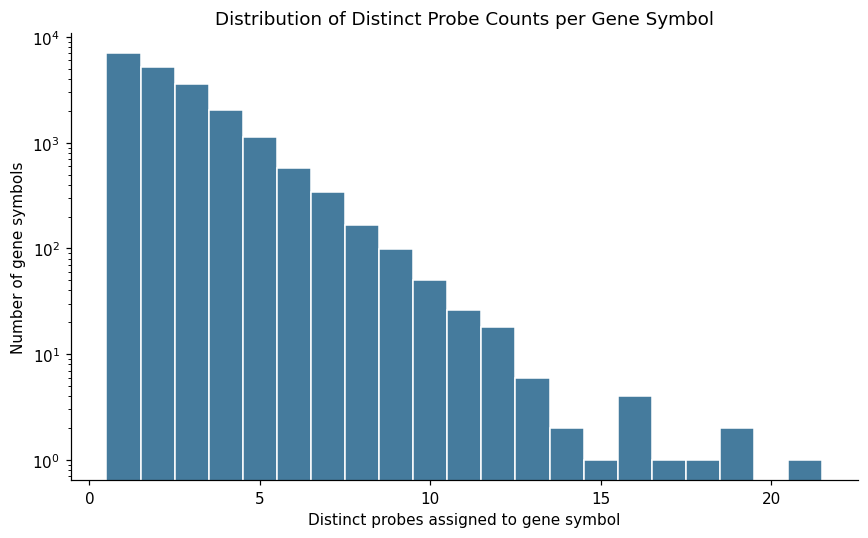

In [4]:
maximum_count = int(probe_counts["probe_count"].max())
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(
    probe_counts["probe_count"],
    bins=np.arange(0.5, maximum_count + 1.5, 1),
    color="#457B9D",
    edgecolor="white",
)
ax.set_title("Distribution of Distinct Probe Counts per Gene Symbol")
ax.set_xlabel("Distinct probes assigned to gene symbol")
ax.set_ylabel("Number of gene symbols")
ax.set_yscale("log")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "probes_per_gene_distribution.png", dpi=180, bbox_inches="tight")
plt.show()

## Collapse to One Representative Probe per Gene

For each expanded gene symbol, the representative is the probe with the smallest adjusted p-value. Absolute paired mean difference and probe ID are used only to break ties deterministically. The original probe ID and total mapped-probe count remain in the output.

In [5]:
gene_summary = collapse_to_gene_level(annotated_ranking)
GENE_OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
gene_summary.to_csv(GENE_OUTPUT_PATH, index=False)

print(f"Gene-level rows: {len(gene_summary):,}")
print(f"Unique gene symbols: {gene_summary['gene_symbol'].nunique():,}")
print(f"Saved local summary: {GENE_OUTPUT_PATH.relative_to(PROJECT_ROOT)}")
display(
    gene_summary[
        [
            "gene_symbol",
            "probe_id",
            "probe_count",
            "gene_title",
            "mean_paired_difference",
            "adjusted_p_value",
        ]
    ].head(15)
)

Gene-level rows: 20,217
Unique gene symbols: 20,217
Saved local summary: data\processed\tumor_vs_paired_normal_gene_level_summary.csv


,gene_symbol,probe_id,probe_count,gene_title,mean_paired_difference,adjusted_p_value
0,CLDN1,11728232_a_at,4,claudin 1,4.920208,5.145358e-59
1,KIAA1199,11735833_a_at,2,KIAA1199,4.699381,2.508659e-58
2,ETV4,11719434_a_at,2,ets variant 4,3.297047,8.376406e-56
3,SLC6A6,11721993_at,5,solute carrier family 6 (neurotransmitter tran...,3.303735,8.495091e-56
4,CA7,11733581_a_at,1,carbonic anhydrase VII,-4.651000,5.584336e-55
5,CDH3,11739128_a_at,2,"cadherin 3, type 1, P-cadherin (placental)",3.592385,6.954774e-55
6,OTOP2,11759464_at,2,otopetrin 2,-5.157509,5.053490e-54
7,GUCA2B,11732838_at,1,guanylate cyclase activator 2B (uroguanylin),-6.547316,2.533048e-53
8,ABCA8,11721557_a_at,5,"ATP-binding cassette, sub-family A (ABC1), mem...",-4.280251,2.923551e-52
9,GTF2IRD1,11750604_a_at,1,GTF2I repeat domain containing 1,2.372823,2.923551e-52


## Largest Absolute Representative-Probe Differences

In [6]:
top_absolute_difference = (
    gene_summary.assign(
        absolute_paired_difference=gene_summary["mean_paired_difference"].abs()
    )
    .sort_values(["absolute_paired_difference", "adjusted_p_value"], ascending=[False, True])
    .head(15)
)
display(
    top_absolute_difference[
        [
            "gene_symbol",
            "probe_id",
            "probe_count",
            "mean_paired_difference",
            "adjusted_p_value",
        ]
    ]
)

,gene_symbol,probe_id,probe_count,mean_paired_difference,adjusted_p_value
66,CA1,11729583_x_at,3,-7.717337,7.322387e-45
277,CLCA4,11728771_a_at,2,-7.269623,1.024773e-38
18,TMIGD1,11737294_a_at,1,-6.928715,1.078155e-49
12,AQP8,11726764_at,1,-6.616658,2.401850e-51
211,MS4A12,11733744_at,1,-6.607507,4.222565e-40
7,GUCA2B,11732838_at,1,-6.547316,2.533048e-53
205,CA4,11730973_a_at,1,-6.211607,3.076556e-40
88,GUCA2A,11731957_at,1,-6.047716,1.001690e-43
16,FOXQ1,11758028_s_at,2,5.660094,7.432698e-50
21,ADH1B,11746898_x_at,6,-5.587003,6.061237e-49


## Gene-Level Representative-Probe Volcano Plot

Each point represents one gene symbol through its selected probe. Highlighting is descriptive and does not define biological importance.

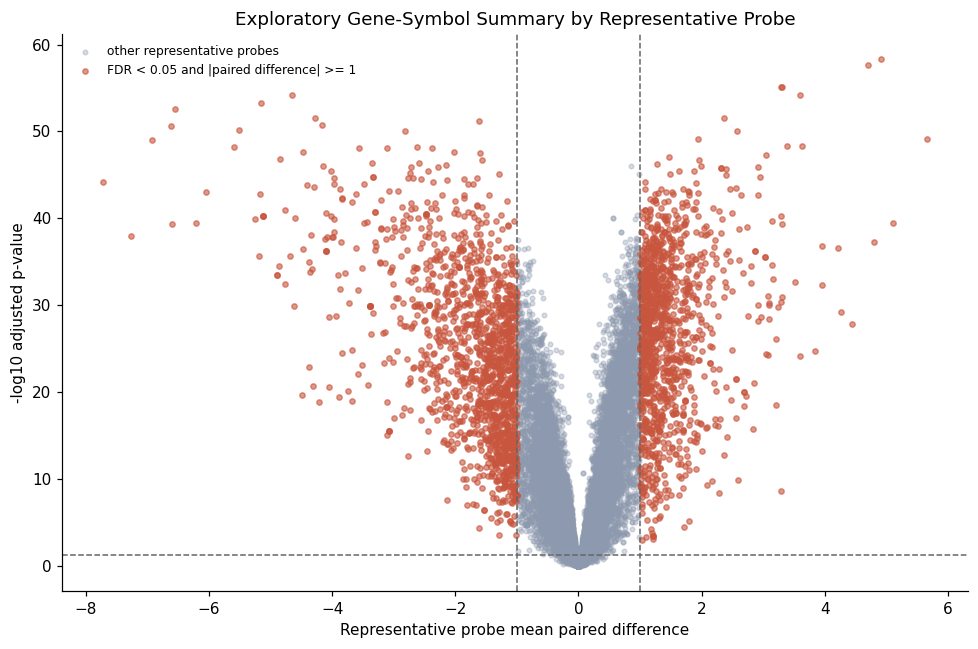

In [7]:
plot_table = gene_summary.copy()
plot_table["minus_log10_adjusted_p"] = -np.log10(
    plot_table["adjusted_p_value"].clip(lower=np.finfo(float).tiny)
)
plot_table["highlight"] = (
    (plot_table["adjusted_p_value"] < 0.05)
    & (plot_table["mean_paired_difference"].abs() >= 1)
)

fig, ax = plt.subplots(figsize=(9, 6))
background = plot_table[~plot_table["highlight"]]
highlighted = plot_table[plot_table["highlight"]]
ax.scatter(
    background["mean_paired_difference"],
    background["minus_log10_adjusted_p"],
    s=9,
    alpha=0.35,
    color="#8D99AE",
    label="other representative probes",
)
ax.scatter(
    highlighted["mean_paired_difference"],
    highlighted["minus_log10_adjusted_p"],
    s=12,
    alpha=0.6,
    color="#C8553D",
    label="FDR < 0.05 and |paired difference| >= 1",
)
ax.axvline(-1, color="#666666", linestyle="--", linewidth=1)
ax.axvline(1, color="#666666", linestyle="--", linewidth=1)
ax.axhline(-np.log10(0.05), color="#666666", linestyle="--", linewidth=1)
ax.set_title("Exploratory Gene-Symbol Summary by Representative Probe")
ax.set_xlabel("Representative probe mean paired difference")
ax.set_ylabel("-log10 adjusted p-value")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "gene_level_volcano.png", dpi=180, bbox_inches="tight")
plt.show()

## Exploratory Top Gene-Level Heatmap

The heatmap uses the representative probes for 20 top-ranked gene symbols and displays within-pair tumor-minus-normal differences across the 98 matched individuals. This is an exploratory representative-probe visualization, not a biomarker heatmap.

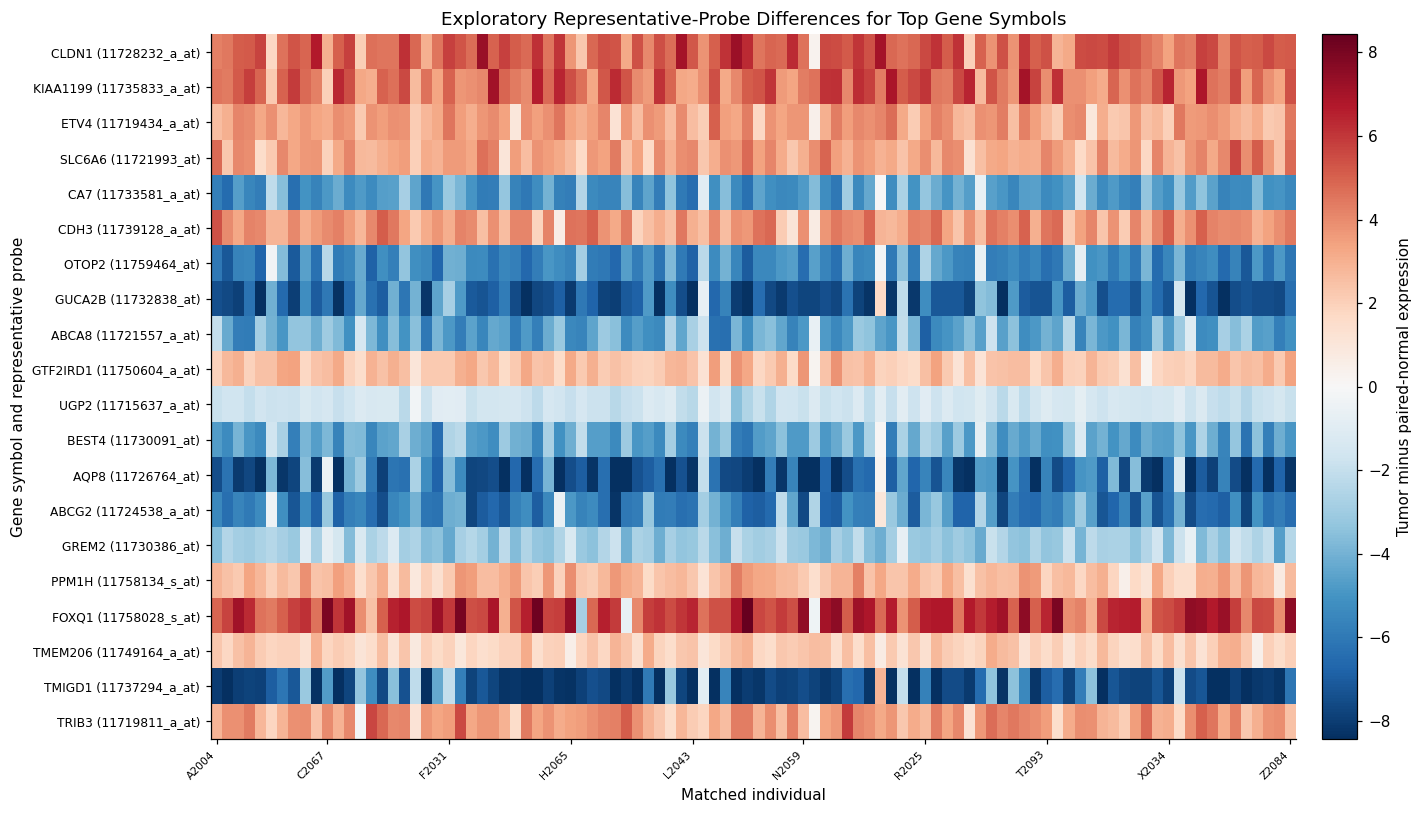

In [8]:
expression, sample_metadata, pair_table = load_expression_metadata_and_pairs()
top_gene_rows = gene_summary.head(20).copy()
top_probe_ids = top_gene_rows["probe_id"].tolist()
indexed_expression = expression.set_index("ID_REF")
tumor_values = indexed_expression.loc[top_probe_ids, pair_table["tumor"]].to_numpy()
normal_values = indexed_expression.loc[
    top_probe_ids,
    pair_table["paired_normal_mucosa"],
].to_numpy()
paired_differences = tumor_values - normal_values
color_limit = float(np.nanquantile(np.abs(paired_differences), 0.98))
row_labels = [
    f"{gene} ({probe})"
    for gene, probe in zip(
        top_gene_rows["gene_symbol"],
        top_gene_rows["probe_id"],
        strict=True,
    )
]

fig, ax = plt.subplots(figsize=(14, 7.5))
image = ax.imshow(
    paired_differences,
    aspect="auto",
    cmap="RdBu_r",
    vmin=-color_limit,
    vmax=color_limit,
)
ax.set_title("Exploratory Representative-Probe Differences for Top Gene Symbols")
ax.set_xlabel("Matched individual")
ax.set_ylabel("Gene symbol and representative probe")
ax.set_yticks(range(len(row_labels)), labels=row_labels, fontsize=8)
tick_positions = np.linspace(0, len(pair_table) - 1, 10, dtype=int)
ax.set_xticks(
    tick_positions,
    labels=pair_table.iloc[tick_positions]["pair_id"],
    rotation=45,
    ha="right",
    fontsize=7,
)
colorbar = fig.colorbar(image, ax=ax, pad=0.02)
colorbar.set_label("Tumor minus paired-normal expression")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "top_gene_level_heatmap.png", dpi=180, bbox_inches="tight")
plt.show()

## Limitations

- Selecting the smallest-adjusted-p probe favors the strongest probe-level statistical result and does not combine evidence across probes.
- Different probes assigned to one symbol may target different transcripts, behave differently, or disagree in direction.
- Multi-symbol probe assignments are expanded, so a single probe may represent more than one gene-symbol row.
- Adjusted p-values remain those from the probe-level analysis; they are not recalculated after gene collapse.
- The GPL13667 annotation is older and incomplete, and gene symbols may have changed.
- This table is useful for organizing follow-up checks, not for pathway, mechanistic, diagnostic, or clinical interpretation.